# Fase 3 Avanzada: K-Fold Cross Validation con Ponderación Poblacional
Este notebook utiliza el dataset con metadatos pasivos, separa el factor de ponderación (`HV005`) y el año/ubigeo/region, y entrena un modelo CatBoost usando `StratifiedKFold`.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Cargando el dataset enriquecido...")
# Cargamos el archivo v2 que acabas de crear
df = pd.read_parquet('../../data/processed/master_preprocessed_v2.parquet')
print(f"Dimensiones: {df.shape}")

Cargando el dataset enriquecido...
Dimensiones: (285284, 80)


In [ ]:
# 1. IDENTIFICAR Y SEPARAR METADATOS
metadata_cols = ['year', 'SHREGION', 'HV005']
cols_to_extract = [c for c in metadata_cols if c in df.columns]

metadata = df[cols_to_extract].copy()
y = df['TARGET_DESNUTRICION']

# Eliminamos Target y Metadatos de los features de entrenamiento para evitar contaminación
X = df.drop(columns=['TARGET_DESNUTRICION'] + cols_to_extract)

# 2. CALCULAR PESO MUESTRAL (Factor de Ponderación)
# Según manual ENDES, HV005 tiene 6 decimales implícitos, por lo que se divide entre 1,000,000
if 'HV005' in metadata.columns:
    sample_weight = metadata['HV005'] / 1000000.0
else:
    sample_weight = pd.Series(np.ones(len(metadata)))

print("Metadatos aislados exitosamente. La IA no hará trampa.")
print(f"Features puras para entrenamiento: {X.shape[1]}")

In [ ]:
import sys
sys.path.append('../../')
from mnp.configs.column_labels import LABELS

X = X.rename(columns=LABELS)
print("Columnas renombradas a formato legible.")

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix
import catboost as cb

# Identificar columnas categóricas
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_features:
    X[col] = X[col].fillna("MISSING").astype(str)

# Configurar K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
recall_scores = []
umbral_medico = 0.4524  # Nuestro umbral optimizado para alta sensibilidad

print("Iniciando K-Fold Cross Validation (5 Folds) con Pesos Muestrales...")
fold = 1
for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_train, w_val = sample_weight.iloc[train_idx], sample_weight.iloc[val_idx]
    
    model = cb.CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        cat_features=cat_features,
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=False
    )
    
    # AQUI ESTA LA MAGIA: Le pasamos los pesos poblacionales al entrenamiento
    model.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_val, y_val), verbose=False)
    
    y_probs = model.predict_proba(X_val)[:, 1]
    y_pred = (y_probs >= umbral_medico).astype(int)
    
    auc = roc_auc_score(y_val, y_probs, sample_weight=w_val)
    recall = recall_score(y_val, y_pred, sample_weight=w_val)
    
    auc_scores.append(auc)
    recall_scores.append(recall)
    
    print(f"Fold {fold} - AUC Ponderado: {auc:.4f} | Recall Ponderado: {recall:.4f}")
    fold += 1

print(f"\n--- RESULTADOS CIENTÍFICOS FINALES (5-Fold CV) ---")
print(f"AUC Promedio:    {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Recall Promedio: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")

In [ ]:
print("Entrenando Modelo Final de Producción con el 100% de los datos y Pesos Muestrales...")
final_model = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100
)

final_model.fit(X, y, sample_weight=sample_weight)
print("¡Modelo Maestro Entrenado!")

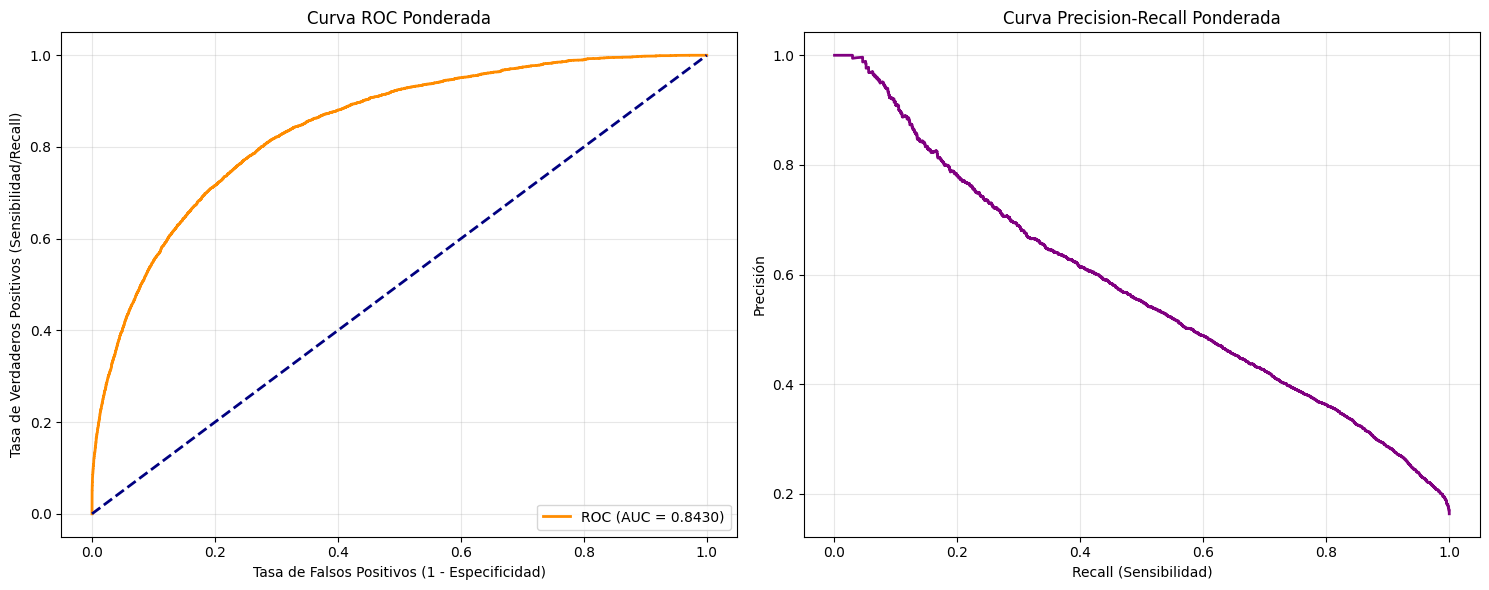

In [7]:
# 7. CURVAS ROC Y PRECISION-RECALL (Basado en el último Fold de validación)
from sklearn.metrics import roc_curve, precision_recall_curve

# Usamos los datos del último fold (Fold 5) que quedaron en memoria para visualizar
fpr, tpr, roc_thresholds = roc_curve(y_val, y_probs, sample_weight=w_val)
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_probs, sample_weight=w_val)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_scores[-1]:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad/Recall)')
axes[0].set_title('Curva ROC Ponderada')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Curva PR
axes[1].plot(recall[:-1], precision[:-1], color='purple', lw=2)
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Curva Precision-Recall Ponderada')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 8. CÁLCULO DEL NUEVO UMBRAL MÉDICO ÓPTIMO
# Como las probabilidades cambiaron al usar los pesos reales del país,
# el antiguo umbral (0.45) ya no sirve. Calculamos el nuevo para atrapar al 80%.

target_recall = 0.80
# Buscamos el índice donde el recall es lo más cercano posible al 80%
idx = np.abs(recall[:-1] - target_recall).argmin()

nuevo_umbral = pr_thresholds[idx]
nueva_precision = precision[idx]

print("🎯 CALIBRACIÓN CLÍNICA (Ajustada por Demografía ENDES):")
print(f"Para atrapar al {target_recall*100}% de los niños desnutridos...")
print(f"➜ El NUEVO umbral óptimo de CatBoost es: {nuevo_umbral:.4f}")
print(f"➜ A este umbral, la precisión será de: {nueva_precision*100:.2f}%")

🎯 CALIBRACIÓN CLÍNICA (Ajustada por Demografía ENDES):
Para atrapar al 80.0% de los niños desnutridos...
➜ El NUEVO umbral óptimo de CatBoost es: 0.1421
➜ A este umbral, la precisión será de: 36.28%


--- MÉTRICAS CON NUEVO UMBRAL MÉDICO (0.1421) ---
                 precision    recall  f1-score   support

      Sanos (0)       0.95      0.72      0.82 0.025753334484999623
Desnutridos (1)       0.36      0.80      0.50 0.005043279350999975

       accuracy                           0.74 0.030796613835999596
      macro avg       0.66      0.76      0.66 0.030796613835999596
   weighted avg       0.85      0.74      0.77 0.030796613835999596



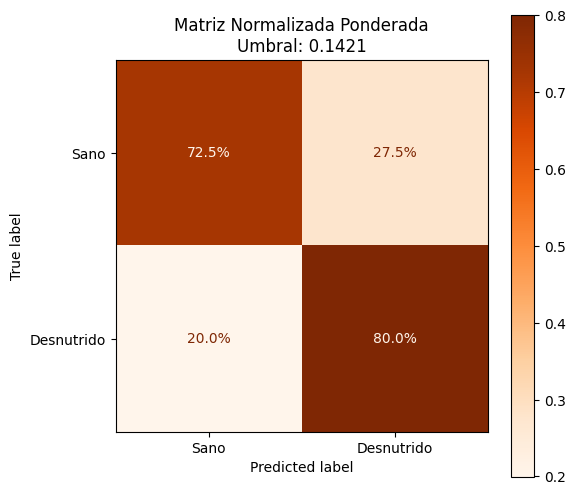

In [9]:
# 9. MATRIZ DE CONFUSIÓN NORMALIZADA CON EL NUEVO UMBRAL
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_ajustado = (y_probs >= nuevo_umbral).astype(int)

print(f"--- MÉTRICAS CON NUEVO UMBRAL MÉDICO ({nuevo_umbral:.4f}) ---")
print(classification_report(y_val, y_pred_ajustado, sample_weight=w_val, target_names=['Sanos (0)', 'Desnutridos (1)']))

cm_norm = confusion_matrix(y_val, y_pred_ajustado, sample_weight=w_val, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Sano', 'Desnutrido'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_norm.plot(cmap='Oranges', values_format='.1%', ax=ax)
plt.title(f'Matriz Normalizada Ponderada\nUmbral: {nuevo_umbral:.4f}')
plt.show()

Extrayendo el ADN de la Desnutrición Infantil...


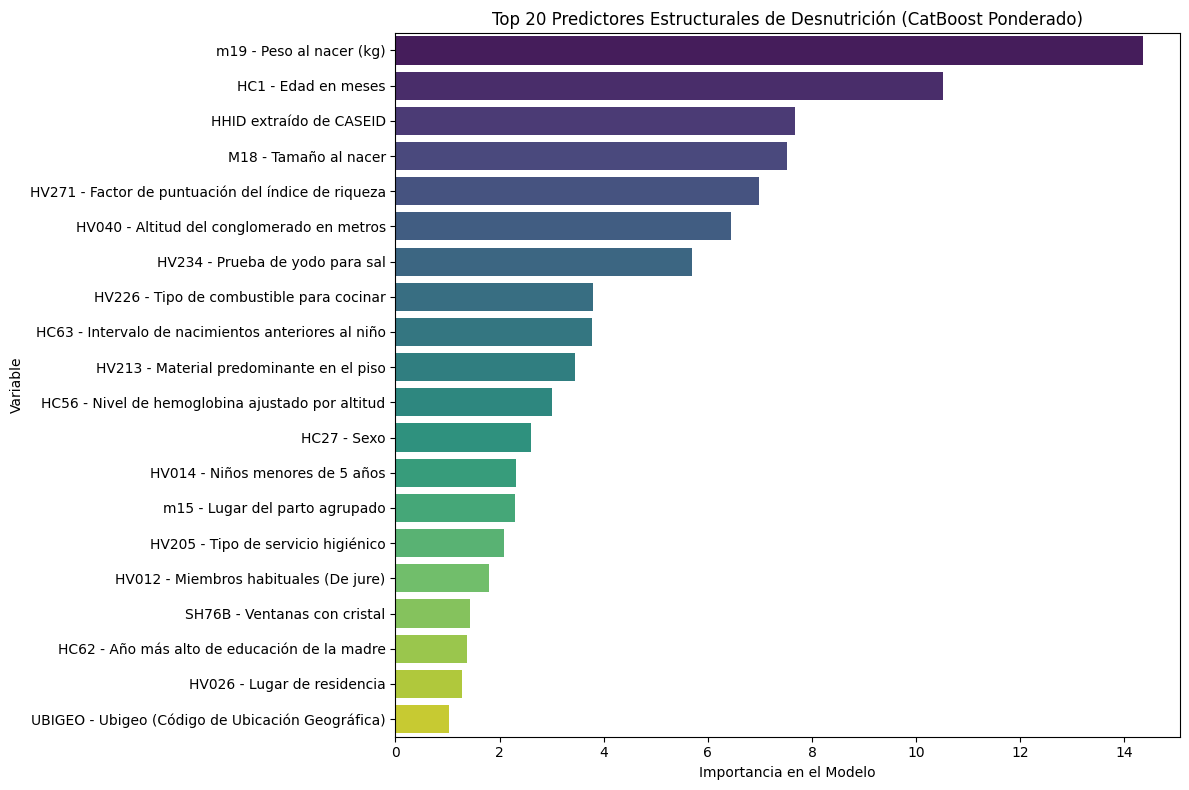

In [10]:
# 10. IMPORTANCIA DE VARIABLES (SHAP / Feature Importance del Modelo Maestro)
# Usamos el final_model que entrenó con el 100% de los datos y pesos.

print("Extrayendo el ADN de la Desnutrición Infantil...")
importances = final_model.get_feature_importance()
feature_names = X.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 20 Predictores Estructurales de Desnutrición (CatBoost Ponderado)')
plt.xlabel('Importancia en el Modelo')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()